# GABLS3 LES Intercomparison Study for Stable Boundary Layers: Time–Height Diagnostics

In [1]:
from IPython.display import display, Markdown
from datetime import datetime, timezone
display(Markdown(f"*Last run: {datetime.now(timezone.utc).strftime('%B %d, %Y at %H:%M UTC')}*"))

*Last run: June 24, 2026 at 09:27 UTC*

This notebook visualizes the JAX-ALFA simulation of the GABLS3 intercomparison case. The simulation covers 9 hours from 00 UTC to 09 UTC, 2 July 2006, at Cabauw, Netherlands.

| Quantity | Value                                                   |
| --- |---------------------------------------------------------|
| Domain | 800 m × 800 m × 800 m                                   |
| Grid | $256^3$                                                 |
| Time step | 0.1 s                                                   |
| Simulation time | 32 400 s (9 h)                                          |
| Roughness length | $z_0 = 0.15$ m                                          |
| Screen temperature/humidity height | $z_T = z_Q = 0.25$ m                                    |
| Geostrophic wind | time- and height-varying ($\texttt{optGeoWind}=1$)      |
| Large-scale advection | time- and height-varying ($\texttt{optAdvection}=1$)    |
| Moisture | prognostic specific humidity ($\texttt{optMoisture}=1$) |
| SGS model | LASDD-SM ($\texttt{optSgs}=1$)                          |

Figures show **time–height** contour plots of mean wind, potential temperature,
specific humidity, resolved variances, and total (resolved + SGS) fluxes.

## Setup

In [1]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

### Output directory and case configuration

In [2]:
from pathlib import Path
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate jaxalfa repository root')

BaseDir = find_repo_root()
RunDir    = BaseDir / 'examples/SBL_GABLS3/runs/256x256x256_LASDD_SM_SP'
OutputDir = RunDir / 'output'

# Read case parameters directly from Config.py so the notebook stays in sync.
_cfg = {}
exec((RunDir / 'Config.py').read_text(), _cfg)

nz                 = int(_cfg['nz'])
l_z                = float(_cfg['l_z'])
dt                 = float(_cfg['dt'])
SimTime            = float(_cfg['SimTime'])
T_0                = float(_cfg['T_0'])
optGeoWind         = int(_cfg.get('optGeoWind', 0))
optAdvection       = int(_cfg.get('optAdvection', 0))
optMoisture        = int(_cfg.get('optMoisture', 0))
optSgs             = int(_cfg['optSgs'])
OutputInterval_sec = float(_cfg['OutputInterval_sec'])

print('BaseDir:', BaseDir)
print('RunDir: ', RunDir)
print(f'nz={nz}, l_z={l_z:g} m, dt={dt:g} s, OutputInterval={OutputInterval_sec:g} s')
print(f'optGeoWind={optGeoWind}, optAdvection={optAdvection}, '
      f'optMoisture={optMoisture}, optSgs={optSgs}')

BaseDir: /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/jaxalfa
RunDir:  /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/jaxalfa/examples/SBL_GABLS3/runs/256x256x256_LASDD_SM_SP
nz=256, l_z=800 m, dt=0.05 s, OutputInterval=300 s
optGeoWind=1, optAdvection=1, optMoisture=1, optSgs=1


### Vertical grid

In [3]:
dz = l_z / (nz - 1)

# Half levels — U, V, TH, Q, u2, v2, TH2, Q2
z = np.array([(k + 0.5) * dz for k in range(nz)])

# Full (staggered) levels — w, uw, vw, wTH, wQ, txz, tyz, qz, qHz, w2
z_w = np.array([k * dz for k in range(nz)])

print(f'dz = {dz:.3f} m,  z[0] = {z[0]:.3f} m,  z[-1] = {z[-1]:.3f} m')

dz = 3.137 m,  z[0] = 1.569 m,  z[-1] = 801.569 m


### Load output files

In [4]:
stat_files = sorted(
    glob.glob(str(OutputDir / 'ALFA_Statistics_Iteration_*.npz')),
    key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
)
n_files = len(stat_files)
missing_stats = (n_files == 0)

print(f'Found {n_files} output files in {OutputDir}')

if n_files == 0:
    raise FileNotFoundError(
        f'No statistics files found in {OutputDir}. Run the GABLS3 case first; '
        'the notebook expects ALFA_Statistics_Iteration_*.npz files.'
    )

Found 108 output files in /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/jaxalfa/examples/SBL_GABLS3/runs/256x256x256_LASDD_SM_SP/output


In [5]:
# Build UTC time axis from file iteration numbers.
# GABLS3 simulation starts at 00 UTC, so no offset needed.
if missing_stats:
    t_hours = np.array([0.0, SimTime / 3600.0])
else:
    iterations = np.array([
        int(re.search(r'Iteration_(\d+)', f).group(1)) for f in stat_files
    ])
    t_hours = iterations * dt / 3600.0    # UTC hours (0-9)

print(f'Time range: {t_hours[0]:.3f} - {t_hours[-1]:.2f} UTC h')


Time range: 0.083 - 9.00 UTC h


In [6]:
# Allocate (n_files, nz) arrays.
U   = np.zeros((n_files, nz))
V   = np.zeros((n_files, nz))
TH  = np.zeros((n_files, nz))
u2  = np.zeros((n_files, nz))
v2  = np.zeros((n_files, nz))
w2  = np.zeros((n_files, nz))
TH2 = np.zeros((n_files, nz))
uw  = np.zeros((n_files, nz))
vw  = np.zeros((n_files, nz))
wTH = np.zeros((n_files, nz))
txz = np.zeros((n_files, nz))
tyz = np.zeros((n_files, nz))
qz  = np.zeros((n_files, nz))
ustar  = np.zeros(n_files)
qz_sfc = np.zeros(n_files)

# Moisture arrays (populated only when optMoisture >= 1).
Q      = np.zeros((n_files, nz))
Q2     = np.zeros((n_files, nz))
wQ     = np.zeros((n_files, nz))
qHz    = np.zeros((n_files, nz))
qm_sfc = np.zeros(n_files)

if missing_stats:
    for arr in [U, V, TH, u2, v2, w2, TH2, uw, vw, wTH, txz, tyz, qz,
                Q, Q2, wQ, qHz]:
        arr[:] = np.nan
    ustar[:] = np.nan
    qz_sfc[:] = np.nan
    qm_sfc[:] = np.nan

for i, f in enumerate(stat_files):
    with np.load(f) as d:
        U[i]   = d['U']
        V[i]   = d['V']
        TH[i]  = d['TH']
        u2[i]  = d['u2']
        v2[i]  = d['v2']
        w2[i]  = d['w2']
        TH2[i] = d['TH2']
        uw[i]  = d['uw']
        vw[i]  = d['vw']
        wTH[i] = d['wTH']
        txz[i] = d['txz']
        tyz[i] = d['tyz']
        qz[i]  = d['qz']
        ustar[i]  = np.asarray(d['ustar']).mean()
        qz_sfc[i] = np.asarray(d['qz_sfc']).mean()
        if optMoisture >= 1:
            Q[i]      = d['Q']
            Q2[i]     = d['Q2']
            wQ[i]     = d['wQ']
            qHz[i]    = d['qHz']
            qm_sfc[i] = np.asarray(d['qm_sfc']).mean()

# Total (resolved + SGS) vertical fluxes.
uw_tot  = uw  + txz
vw_tot  = vw  + tyz
wTH_tot = wTH + qz
wQ_tot  = wQ  + qHz

print('Data loaded.')

Data loaded.


### Plot style

In [7]:
plt.rcParams.update({
    'text.usetex'    : False,
    'font.size'      : 13,
    'axes.labelsize' : 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# GABLS3 is a shallow nocturnal SBL; show only the lowest 600 m.
z_max = 600.0

# UTC tick positions every hour.
utc_ticks = np.arange(0, 10, 1)

def th_plot(ax, t_hours, z_axis, field, cmap, label, z_max=z_max):
    """Standard time-height pcolormesh helper."""
    pc = ax.pcolormesh(t_hours, z_axis, field.T,
                       cmap=cmap, shading='auto')
    cb = plt.colorbar(pc, ax=ax, pad=0.02)
    cb.set_label(label)
    ax.set_xlabel(r'UTC (h)')
    ax.set_ylabel(r'$z$ (m)')
    ax.set_ylim(0, z_max)
    ax.set_xticks(utc_ticks)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    return pc

def symm_limits(data):
    """Return vmin/vmax centred on zero for a diverging colormap."""
    amax = np.nanmax(np.abs(data))
    return -amax, amax

## Mean Wind Components

Time–height evolution of the planar-mean zonal ($U$) and meridional ($V$) wind.

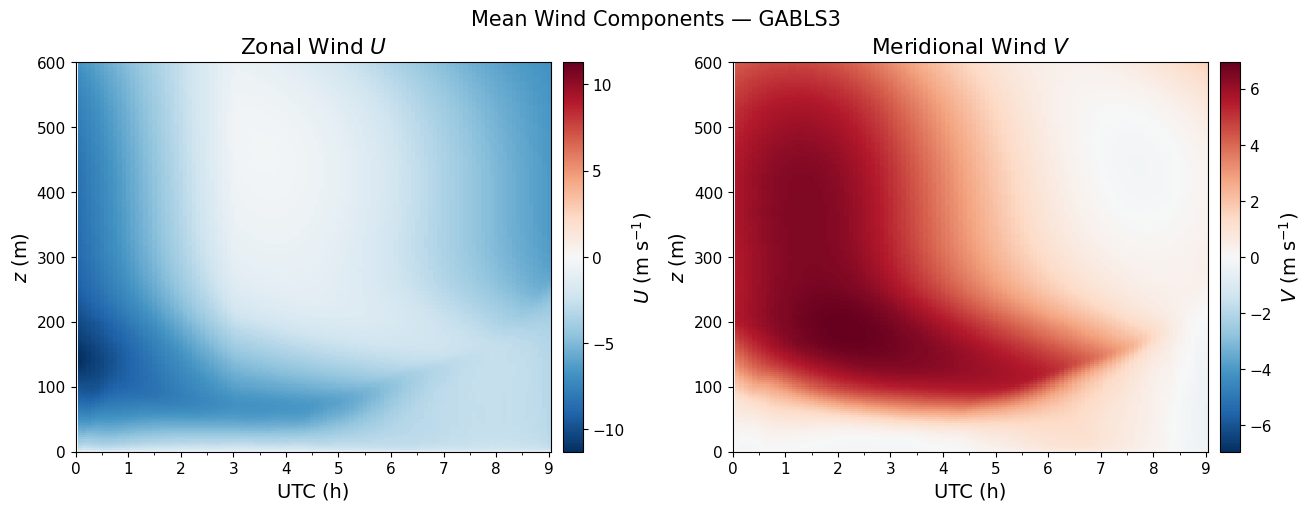

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

pc = th_plot(axs[0], t_hours, z, U, 'RdBu_r', r'$U$ (m s$^{-1}$)')
pc.set_clim(*symm_limits(U[:, z <= z_max]))
axs[0].set_title(r'Zonal Wind $U$')

pc = th_plot(axs[1], t_hours, z, V, 'RdBu_r', r'$V$ (m s$^{-1}$)')
pc.set_clim(*symm_limits(V[:, z <= z_max]))
axs[1].set_title(r'Meridional Wind $V$')

fig.suptitle('Mean Wind Components — GABLS3', fontsize=15)
plt.show()

## Mean Wind Speed

$$S = \sqrt{U^2 + V^2}$$

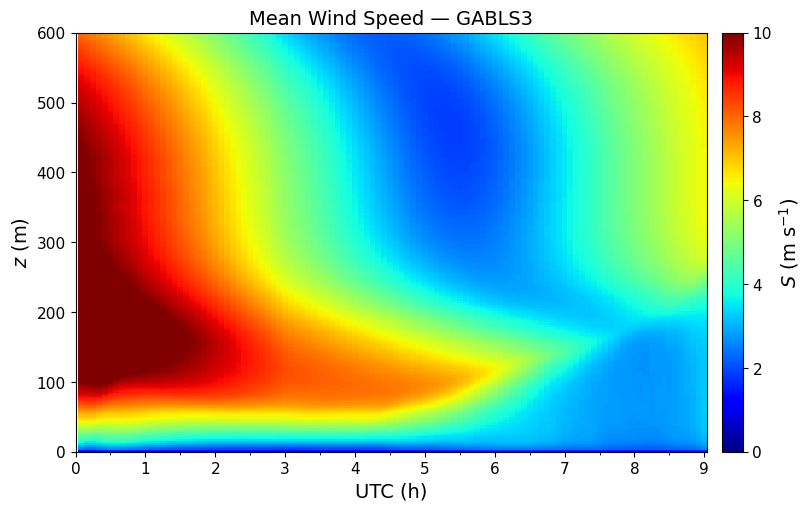

In [9]:
S = np.sqrt(U**2 + V**2)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
pc = th_plot(ax, t_hours, z, S, 'jet', r'$S$ (m s$^{-1}$)')
pc.set_clim(0, 10)
ax.set_title(r'Mean Wind Speed — GABLS3', fontsize=14)
plt.show()

## Mean Potential Temperature

Nocturnal cooling drives a progressively stable stratification from the surface upward.

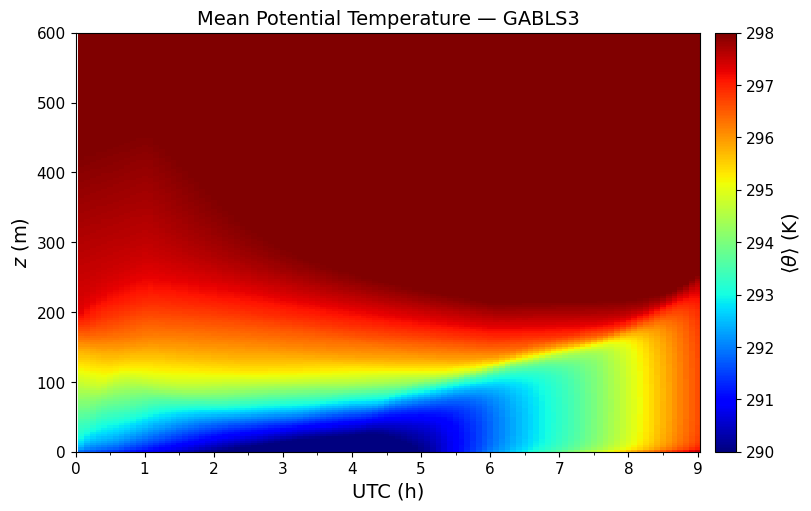

In [10]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

pc = th_plot(ax, t_hours, z, TH, 'jet', r'$\langle\theta\rangle$ (K)')
pc.set_clim(290, 298)
ax.set_title(r'Mean Potential Temperature — GABLS3', fontsize=14)
plt.show()

## Mean Specific Humidity

Moisture transport driven by the nocturnal surface flux and large-scale advection (Table 7).

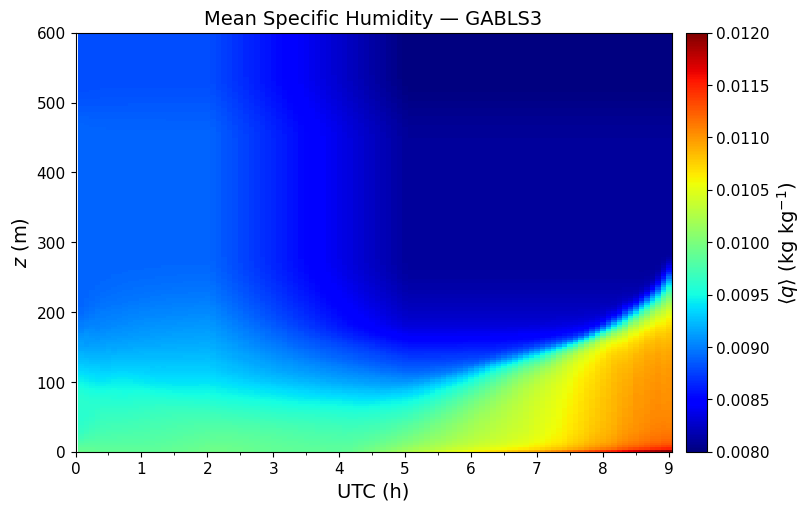

In [11]:
if optMoisture >= 1:
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    pc = th_plot(ax, t_hours, z, Q, 'jet',
                 r'$\langle q \rangle$ (kg kg$^{-1}$)')
    pc.set_clim(0.008, 0.012)
    ax.set_title(r'Mean Specific Humidity — GABLS3', fontsize=14)
    plt.show()
else:
    print('optMoisture = 0: no moisture data.')

## Resolved Velocity Variances

Turbulent activity is confined to the shallow nocturnal SBL.

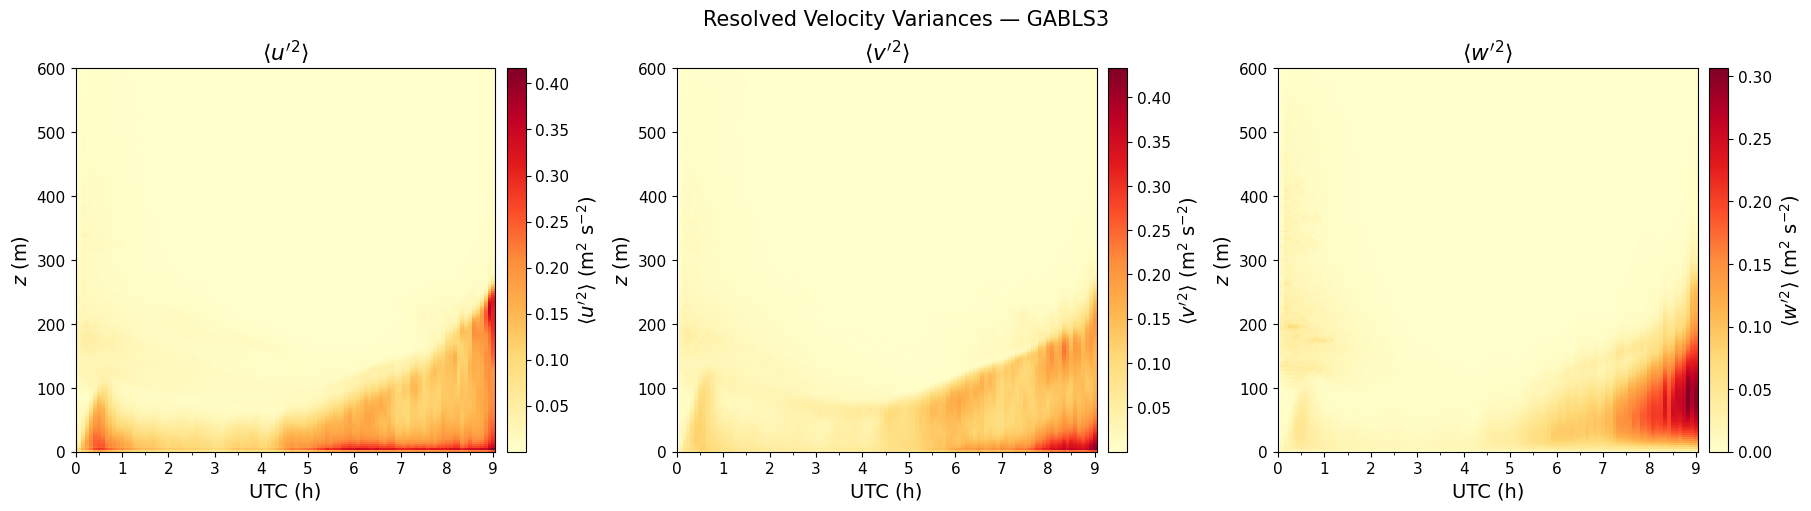

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

th_plot(axs[0], t_hours, z,   u2, 'YlOrRd', r"$\langle u'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[0].set_title(r"$\langle u'^2 \rangle$")

th_plot(axs[1], t_hours, z,   v2, 'YlOrRd', r"$\langle v'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[1].set_title(r"$\langle v'^2 \rangle$")

th_plot(axs[2], t_hours, z_w, w2, 'YlOrRd', r"$\langle w'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[2].set_title(r"$\langle w'^2 \rangle$")

fig.suptitle('Resolved Velocity Variances — GABLS3', fontsize=15)
plt.show()

## Potential Temperature Variance

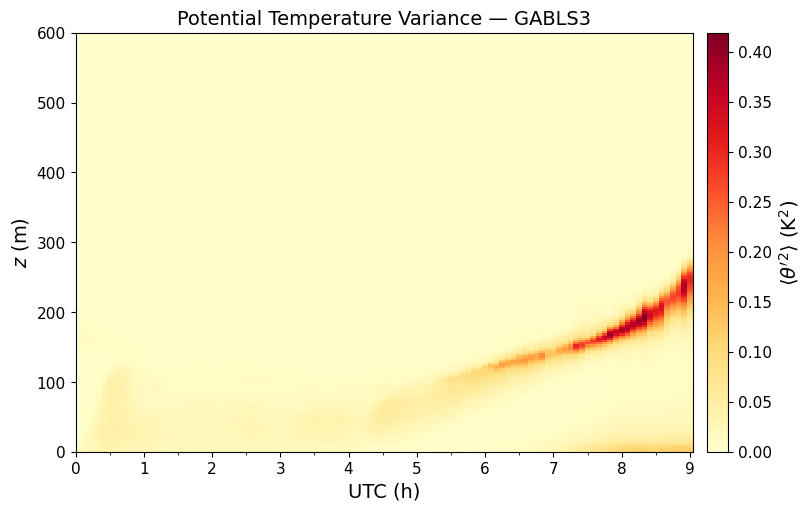

In [13]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

th_plot(ax, t_hours, z, TH2, 'YlOrRd', r"$\langle\theta'^2\rangle$ (K$^2$)")
ax.set_title(r"Potential Temperature Variance — GABLS3", fontsize=14)
plt.show()

## Specific Humidity Variance

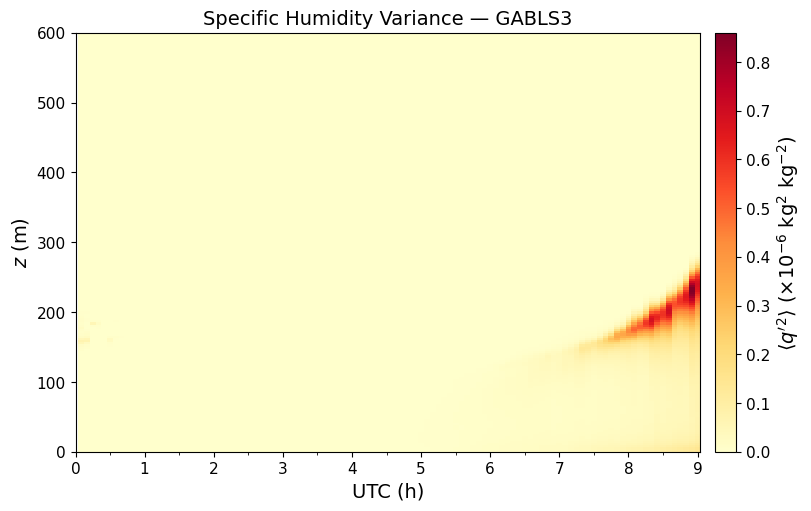

In [14]:
if optMoisture >= 1:
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    th_plot(ax, t_hours, z, Q2 * 1e6, 'YlOrRd',
            r"$\langle q'^2\rangle$ ($\times 10^{-6}$ kg$^2$ kg$^{-2}$)")
    ax.set_title(r"Specific Humidity Variance — GABLS3", fontsize=14)
    plt.show()
else:
    print('optMoisture = 0: no moisture data.')

## Total Momentum Fluxes (Resolved + SGS)

$$\langle u'w' \rangle_{\mathrm{tot}} = \langle u'w' \rangle + \tau_{xz}, \qquad
  \langle v'w' \rangle_{\mathrm{tot}} = \langle v'w' \rangle + \tau_{yz}$$

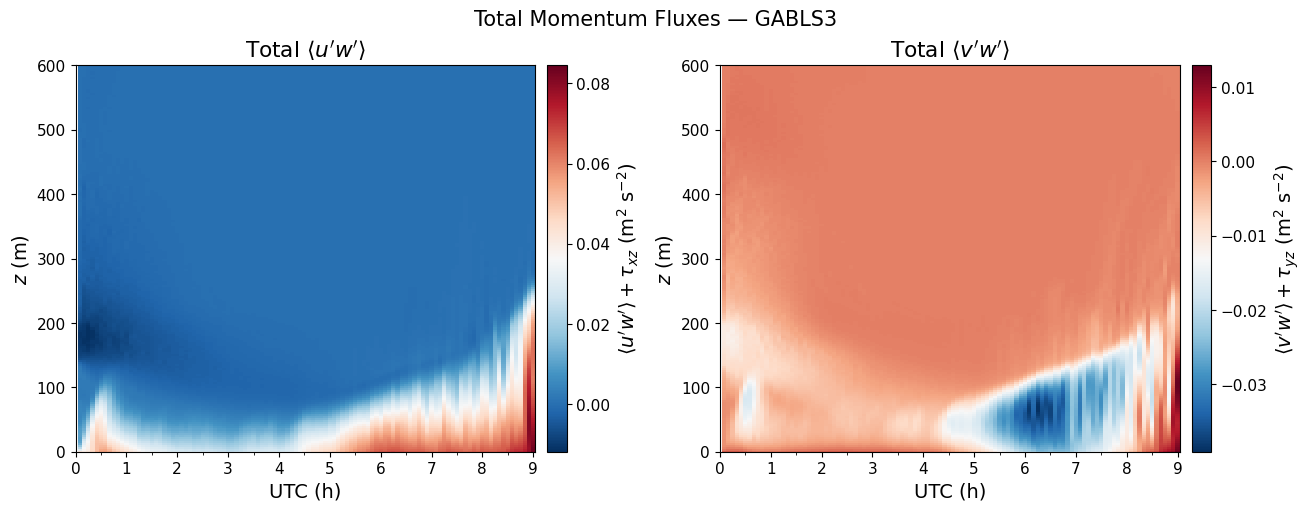

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

th_plot(axs[0], t_hours, z_w, uw_tot, 'RdBu_r',
        r"$\langle u'w'\rangle + \tau_{xz}$ (m$^2$ s$^{-2}$)")
axs[0].set_title(r"Total $\langle u'w' \rangle$")

th_plot(axs[1], t_hours, z_w, vw_tot, 'RdBu_r',
        r"$\langle v'w'\rangle + \tau_{yz}$ (m$^2$ s$^{-2}$)")
axs[1].set_title(r"Total $\langle v'w' \rangle$")

fig.suptitle('Total Momentum Fluxes — GABLS3', fontsize=15)
plt.show()

## Total Heat Flux (Resolved + SGS)

$$\langle w'\theta' \rangle_{\mathrm{tot}} = \langle w'\theta' \rangle + q_z$$

Downward (negative) heat flux throughout the nocturnal period.

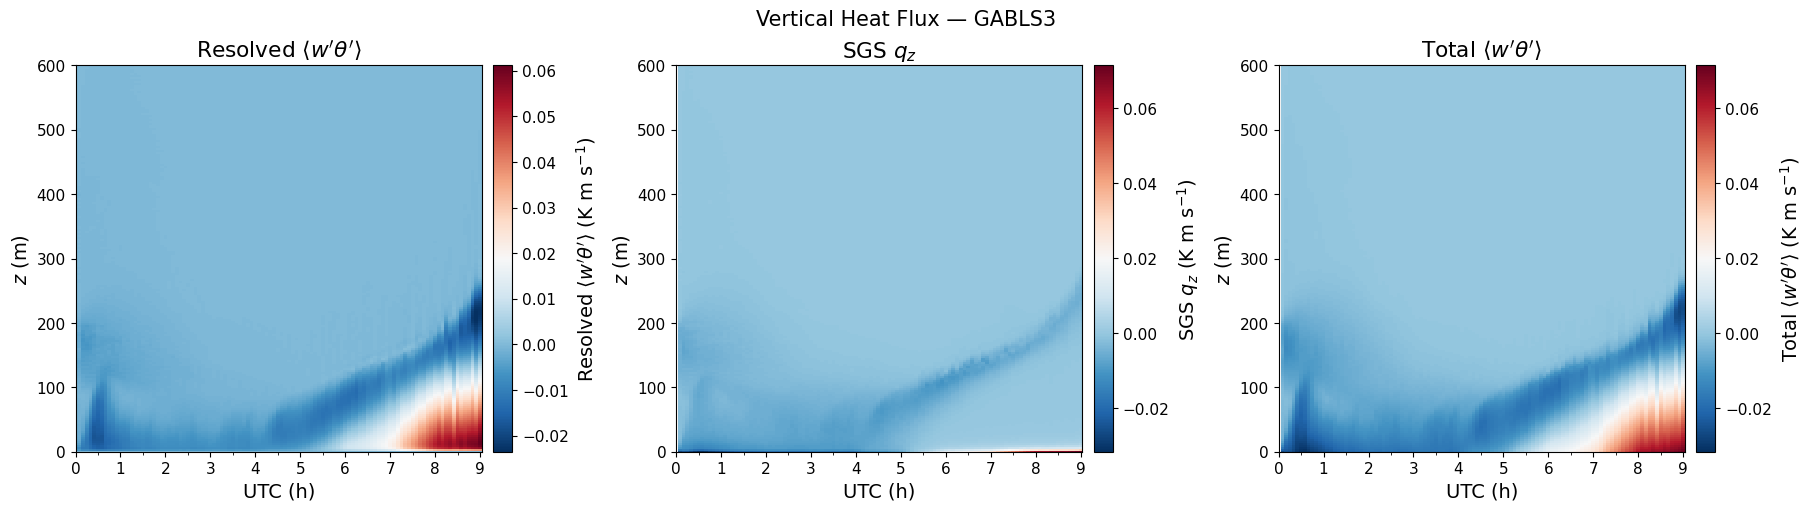

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

th_plot(axs[0], t_hours, z_w, wTH,     'RdBu_r',
        r"Resolved $\langle w'\theta'\rangle$ (K m s$^{-1}$)")
axs[0].set_title(r"Resolved $\langle w'\theta' \rangle$")

th_plot(axs[1], t_hours, z_w, qz,      'RdBu_r',
        r"SGS $q_z$ (K m s$^{-1}$)")
axs[1].set_title(r"SGS $q_z$")

th_plot(axs[2], t_hours, z_w, wTH_tot, 'RdBu_r',
        r"Total $\langle w'\theta'\rangle$ (K m s$^{-1}$)")
axs[2].set_title(r"Total $\langle w'\theta' \rangle$")

fig.suptitle('Vertical Heat Flux — GABLS3', fontsize=15)
plt.show()

## Total Moisture Flux (Resolved + SGS)

$$\langle w'q' \rangle_{\mathrm{tot}} = \langle w'q' \rangle + q_{Hz}$$

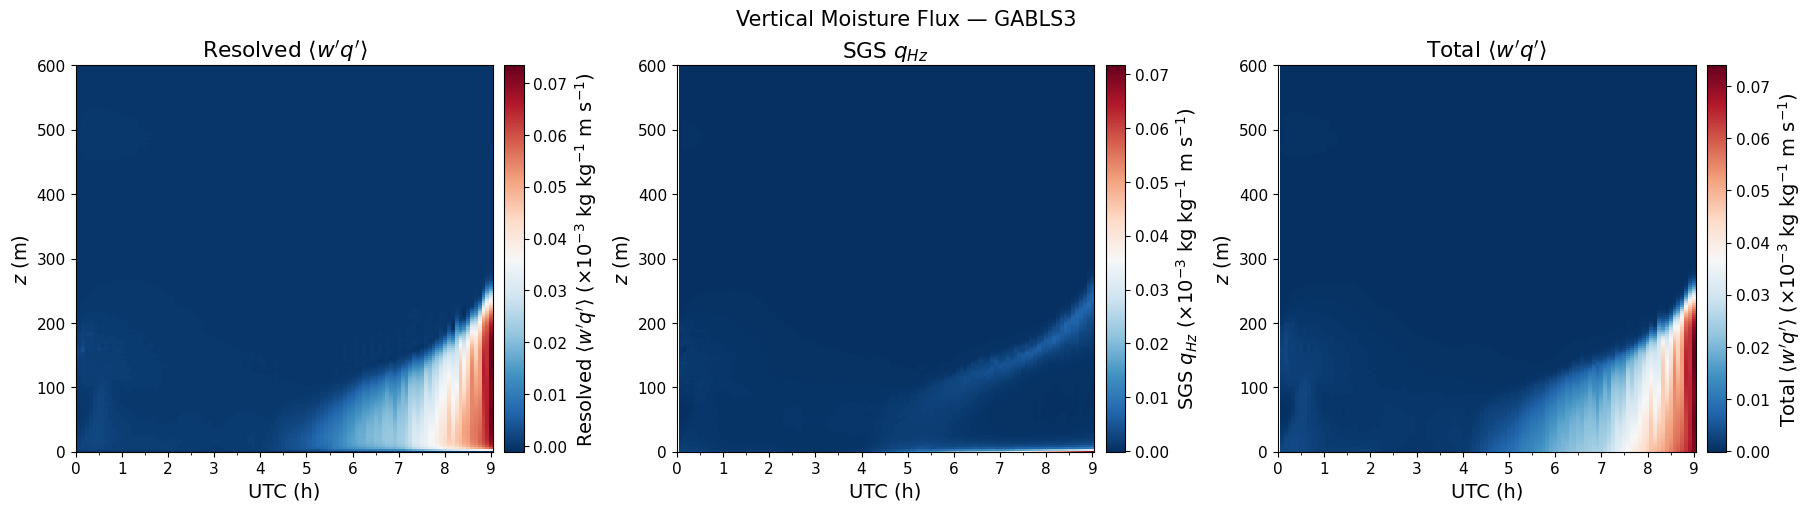

In [17]:
if optMoisture >= 1:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    th_plot(axs[0], t_hours, z_w, wQ * 1e3,     'RdBu_r',
            r"Resolved $\langle w'q'\rangle$ ($\times 10^{-3}$ kg kg$^{-1}$ m s$^{-1}$)")
    axs[0].set_title(r"Resolved $\langle w'q' \rangle$")

    th_plot(axs[1], t_hours, z_w, qHz * 1e3,    'RdBu_r',
            r"SGS $q_{Hz}$ ($\times 10^{-3}$ kg kg$^{-1}$ m s$^{-1}$)")
    axs[1].set_title(r"SGS $q_{Hz}$")

    th_plot(axs[2], t_hours, z_w, wQ_tot * 1e3, 'RdBu_r',
            r"Total $\langle w'q'\rangle$ ($\times 10^{-3}$ kg kg$^{-1}$ m s$^{-1}$)")
    axs[2].set_title(r"Total $\langle w'q' \rangle$")

    fig.suptitle('Vertical Moisture Flux — GABLS3', fontsize=15)
    plt.show()
else:
    print('optMoisture = 0: no moisture data.')

## Surface Time Series

Evolution of friction velocity, surface sensible heat flux, and surface moisture flux.

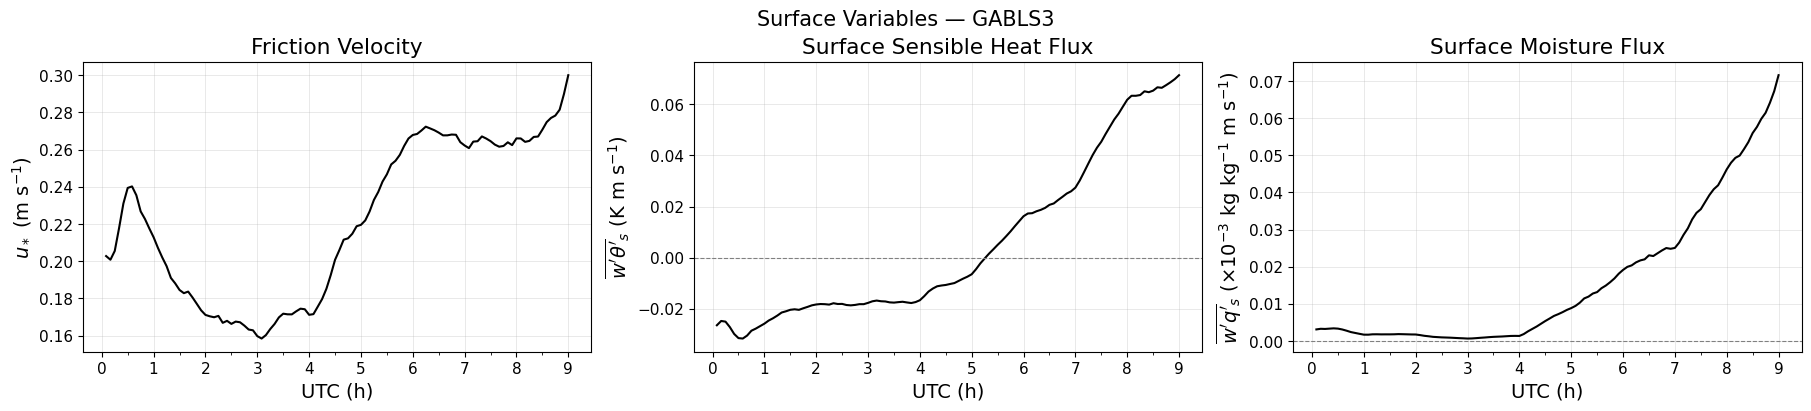

In [18]:
ncols = 3 if optMoisture >= 1 else 2
fig, axs = plt.subplots(1, ncols, figsize=(6 * ncols, 4), constrained_layout=True)

axs[0].plot(t_hours, ustar, 'k', linewidth=1.5)
axs[0].set_xlabel(r'UTC (h)')
axs[0].set_ylabel(r'$u_*$ (m s$^{-1}$)')
axs[0].set_title(r'Friction Velocity')
axs[0].set_xticks(utc_ticks)
axs[0].xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
axs[0].grid(True, which='major', alpha=0.4)

axs[1].plot(t_hours, qz_sfc, 'k', linewidth=1.5)
axs[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axs[1].set_xlabel(r'UTC (h)')
axs[1].set_ylabel(r"$\overline{w'\theta'}_s$ (K m s$^{-1}$)")
axs[1].set_title(r'Surface Sensible Heat Flux')
axs[1].set_xticks(utc_ticks)
axs[1].xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
axs[1].grid(True, which='major', alpha=0.4)

if optMoisture >= 1:
    axs[2].plot(t_hours, qm_sfc * 1e3, 'k', linewidth=1.5)
    axs[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axs[2].set_xlabel(r'UTC (h)')
    axs[2].set_ylabel(r"$\overline{w'q'}_s$ ($\times 10^{-3}$ kg kg$^{-1}$ m s$^{-1}$)")
    axs[2].set_title(r'Surface Moisture Flux')
    axs[2].set_xticks(utc_ticks)
    axs[2].xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    axs[2].grid(True, which='major', alpha=0.4)

fig.suptitle('Surface Variables — GABLS3', fontsize=15)
plt.show()